<a href="https://colab.research.google.com/github/D3deee/DSP-Labs/blob/main/lab03_PJ_G.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 DSP Lab 03: The Machine That Listens (Speech Recognition)

ใน Lab 02 เราได้เรียนรู้การใช้ **FFT** และ **Spectrogram** เพื่อแปลงเสียงให้กลายเป็นภาพ 2 มิติกันไปแล้ว
ใน Lab นี้ เราจะนำ "ภาพ Spectrogram" เหล่านั้นมาป้อนให้ **โครงข่ายประสาทเทียม (Artificial Neural Network - ANN)** เพื่อสอนให้คอมพิวเตอร์ "ฟัง" และ "เข้าใจ" เสียงพูดของมนุษย์!

---

## 🛠️ Step 0: เตรียมเครื่องมือ (Setup)
รัน Cell ด้านล่างเพื่อนำเข้า Library ที่จำเป็น เราจะใช้ `librosa` สำหรับจัดการเสียง และ `TensorFlow/Keras` สำหรับสร้าง AI

In [17]:
import zipfile
import os
import time
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import tensorflow as tf
from tensorflow.keras import layers, models
from IPython.display import Audio, display, HTML, clear_output
from google.colab.output import eval_js
from base64 import b64decode

print("✅ เครื่องมือพร้อมสำหรับการสร้าง AI!")

✅ เครื่องมือพร้อมสำหรับการสร้าง AI!


---
## 📥 Mission 1: Data Harvesting (รวบรวมข้อมูลเสียง)
AI จะฉลาดได้ต้องมีข้อมูลให้เรียนรู้ เราจะดาวน์โหลดชุดข้อมูล **Mini Speech Commands** ซึ่งประกอบด้วยไฟล์เสียงพูดสั้นๆ (1 วินาที)

In [18]:

# Extract using Python's zipfile
if os.path.exists('thai_speech_dataset.zip'):
    with zipfile.ZipFile('thai_speech_dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('data')
    print("Extraction complete. Contents of 'data' folder:", os.listdir('data'))
else:
    print("Error: thai_speech_dataset.zip not found in /content/")

# Adjust data_dir based on actual extracted folder name
# If the zip doesn't have a top-level folder, use 'data'
data_dir = pathlib.Path('data/thai_speech_dataset')
if not os.path.exists(data_dir):
    data_dir = pathlib.Path('data')

# List commands
try:
    commands = np.array(tf.io.gfile.listdir(str(data_dir)))
    # Filter out non-directory files like .DS_Store or zip files
    commands = np.array([c for c in commands if os.path.isdir(os.path.join(data_dir, c))])
    print("คำศัพท์ที่ AI ของเราจะต้องเรียนรู้ (Classes):", commands)
    print("จำนวนคำศัพท์ทั้งหมด =", len(commands), "คำ")

    # Try to find a sample from the first available class
    if len(commands) > 0:
        sample_class = commands[0]
        class_dir = os.path.join(data_dir, sample_class)
        sample_files = os.listdir(class_dir)
        if sample_files:
            sample_audio_path = os.path.join(class_dir, sample_files[0])
            print(f"Playing sample from class: {sample_class}")
            display(Audio(sample_audio_path))
except Exception as e:
    print(f"Error listing directory: {e}")

Extraction complete. Contents of 'data' folder: ['อร่อย', '.ipynb_checkpoints', 'หมา', 'ดำ', 'กิน']
คำศัพท์ที่ AI ของเราจะต้องเรียนรู้ (Classes): ['อร่อย' '.ipynb_checkpoints' 'หมา' 'ดำ' 'กิน']
จำนวนคำศัพท์ทั้งหมด = 5 คำ
Playing sample from class: อร่อย


---
## 🌈 Mission 2: Feature Extraction (The Mel Scale)
AI แบบ CNN เก่งเรื่องการดูรูปภาพ เราจึงต้องแปลงเสียงให้เป็นภาพ **Mel-Spectrogram**

**💡 ทบทวนความรู้จาก Slide:** หูมนุษย์รับรู้ความถี่แบบไม่เป็นเส้นตรง เรามักจะบีบความถี่เป็นแบนด์ (Mel bands) จำนวน 64 แบนด์ และเสียงพูดปกติจะมีความถี่ไม่เกิน 8,000 Hz

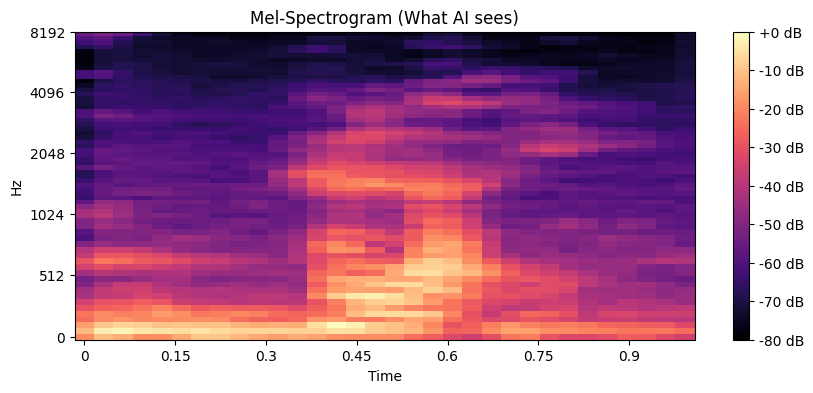

In [20]:
y, sr = librosa.load(sample_audio_path, sr=16000)

# ---------------------------------------------------------
# 🎯 ภารกิจที่ 1: เติมพารามิเตอร์ให้ตรงกับทฤษฎีการได้ยินของมนุษย์
# ---------------------------------------------------------
S = librosa.feature.melspectrogram(y=y, sr=sr,
                                   n_mels=64,
                                   fmax=8000)

S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spectrogram (What AI sees)')
plt.show()

---
## 🧠 Mission 3: Building the Brain (สร้างสมอง AI)
เตรียมข้อมูลเสียงทั้งหมดและสร้างโมเดล **CNN**

**💡 ทบทวนความรู้จาก Slide:** Layer สุดท้ายของ Neural Network (Output Layer) จะต้องมีจำนวนเซลล์เท่ากับ "จำนวนคลาส" ที่เราต้องการแยกแยะ และใช้ฟังก์ชัน Softmax เพื่อแปลงเป็น % ความน่าจะเป็น

In [51]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir, batch_size=64, validation_split=0.5,
    seed=0, output_sequence_length=16000, subset='both')

label_names = np.array(train_ds.class_names)
num_classes = len(label_names) # เก็บจำนวนคำศัพท์ไว้ในตัวแปรนี้

def get_spectrogram(audio, label):
  audio = tf.squeeze(audio, axis=-1)
  spectrogram = tf.signal.stft(audio, frame_length=255, frame_step=128)
  spectrogram = tf.abs(spectrogram)
  spectrogram = tf.expand_dims(spectrogram, -1)
  return spectrogram, label

train_spectrogram_ds = train_ds.map(map_func=get_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)
val_spectrogram_ds = val_ds.map(map_func=get_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)

for example_spectrograms, example_labels in train_spectrogram_ds.take(1):
  input_shape = example_spectrograms.shape[1:]

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Resizing(32, 32),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    # ---------------------------------------------------------
    # 🎯 ภารกิจที่ 2: เติมจำนวน Node ของ Output Layer และ Activation Function
    # คำใบ้: จำนวน Node ใช้ตัวแปร num_classes / ฟังก์ชันใช้ 'softmax'
    # ---------------------------------------------------------
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Found 217 files belonging to 4 classes.
Using 109 files for training.
Using 108 files for validation.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_3 (Resizing)           │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,372 (1.20 MB)

 Trainable params: 314,372 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

---
## ⚔️ Mission 4: Training (กระบวนการฝึกฝน)
**💡 ทบทวนความรู้จาก Slide:** การฝึก AI ต้องทำซ้ำๆ เรียกว่า Epoch ยิ่ง Epoch เยอะ AI ยิ่งได้ทบทวนบทเรียน

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 424ms/step - accuracy: 0.3486 - loss: 1.4426 - val_accuracy: 0.4815 - val_loss: 1.2936
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.5321 - loss: 1.2639 - val_accuracy: 0.5093 - val_loss: 1.2361
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.6330 - loss: 1.1657 - val_accuracy: 0.5278 - val_loss: 1.1770
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.6514 - loss: 1.0546 - val_accuracy: 0.5648 - val_loss: 1.1295
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step - accuracy: 0.6514 - loss: 1.0390 - val_accuracy: 0.6019 - val_loss: 1.0821
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.6881 - loss: 0.9584 - val_accuracy: 0.6019 - val_loss: 1.0490
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step - accuracy: 0.7339 - loss: 0.9143 - val_accuracy: 0.6389 - val_loss: 0.9815
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.6697 - loss: 0.8439 - val_accuracy: 0.6296 - val_loss:

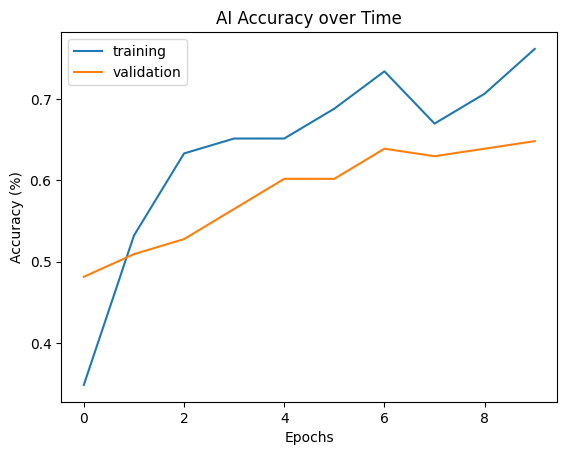

In [52]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ---------------------------------------------------------
# 🎯 ภารกิจที่ 3: กำหนดรอบการฝึกฝน (ลองใส่สัก 10 รอบ)
# ---------------------------------------------------------
EPOCHS = 10

history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=[tf.keras.callbacks.EarlyStopping(verbose=1, patience=2)],
)

metrics = history.history
plt.plot(history.epoch, metrics['accuracy'], metrics['val_accuracy'])
plt.legend(['training', 'validation'])
plt.title('AI Accuracy over Time')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

---
## 🎙️ Mission 5: The Ultimate Test (ทดสอบเสียงของคุณเอง!)
เปิดไมโครโฟน แล้วพูดคำว่า `down, go, left, right, no, yes, stop, up` มา 1 คำ

**💡 ทบทวนความรู้จาก Slide (Data Consistency):** ไฟล์เสียงตอนทดสอบ ต้องมีขนาด Data Points เท่ากับตอนเทรนเป๊ะๆ ถ้าเราใช้เวลา 1 วินาที ที่ Sampling rate 16,000 Hz แปลว่าเราต้องการข้อมูลทั้งหมดกี่จุด?


🤖 AI มั่นใจว่าคุณพูดคำว่า: 👉 [ อร่อย ] 👈



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


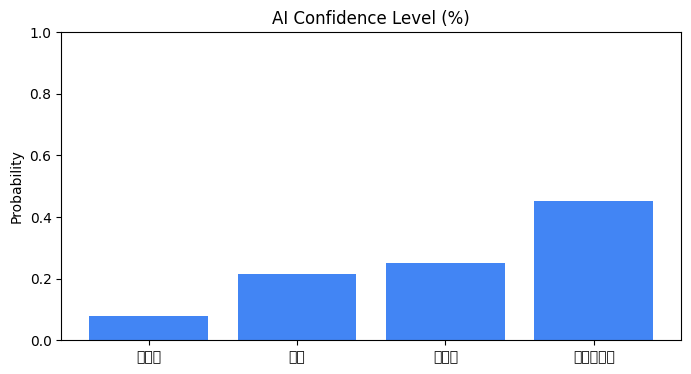

In [57]:
import subprocess
import os

file_id = int(time.time())
webm_file = f'my_test_{file_id}.webm'
wav_file = f'my_test_{file_id}.wav'

AUDIO_HTML = """
<script>
var my_div = document.createElement("DIV");
var my_btn = document.createElement("BUTTON");
my_btn.style.padding = "10px 20px"; my_btn.style.fontSize = "16px"; my_btn.style.cursor = "pointer";
var t = document.createTextNode("🎤 กดเพื่อบันทึกเสียง (1 วินาที)");
my_btn.appendChild(t); my_div.appendChild(my_btn); document.body.appendChild(my_div);
var base64data = 0; var reader; var recorder, gumStream; var recordButton = my_btn;
var handleSuccess = function(stream) {
  gumStream = stream;
  recorder = new MediaRecorder(stream, { mimeType : 'audio/webm;codecs=opus' });
  recorder.ondataavailable = function(e) {
    reader = new FileReader(); reader.readAsDataURL(e.data);
    reader.onloadend = function() { base64data = reader.result; }
  };
  recorder.start(); recordButton.innerText = "🔴 กำลังบันทึก... พูดเลย!";
  setTimeout(() => { recorder.stop(); gumStream.getAudioTracks()[0].stop(); recordButton.innerText = "✅ สำเร็จ! กำลังส่งให้ AI..."; }, 1500);
};
recordButton.onclick = function() { navigator.mediaDevices.getUserMedia({audio: true}).then(handleSuccess); }
function getAudio() { return new Promise(resolve => { var interval = setInterval(() => { if (base64data != 0) { clearInterval(interval); resolve(base64data); } }, 100); }); }
</script>
"""
display(HTML(AUDIO_HTML))
data = eval_js("getAudio()")
binary = b64decode(data.split(',')[1])
with open(webm_file, 'wb') as f: f.write(binary)

# Fix: Use subprocess.run instead of ! shell command to avoid /bin/bash error
subprocess.run(['ffmpeg', '-y', '-i', webm_file, '-ac', '1', '-ar', '16000', wav_file, '-loglevel', 'quiet'])
clear_output()

# ---------------------------------------------------------
# 🎯 ภารกิจที่ 4: Data Consistency (คำนวณจำนวนข้อมูลที่ AI ต้องการ)
# ---------------------------------------------------------
expected_length = 1 * 16000

custom_audio, sr = librosa.load(wav_file, sr=16000)
custom_audio = custom_audio[:expected_length]
if len(custom_audio) < expected_length:
    custom_audio = np.pad(custom_audio, (0, expected_length - len(custom_audio)), 'constant')

tensor_audio = tf.expand_dims(tf.convert_to_tensor(custom_audio), -1)
spec, _ = get_spectrogram(tensor_audio, label=0)
spec = tf.expand_dims(spec, 0)

prediction = model.predict(spec, verbose=0)
predicted_label = label_names[np.argmax(prediction[0])]

print("\n====================================")
print(f"🤖 AI มั่นใจว่าคุณพูดคำว่า: 👉 [ {predicted_label.upper()} ] 👈")
print("====================================\n")

plt.figure(figsize=(8, 4))
plt.bar(label_names, prediction[0], color='#4285f4')
plt.title('AI Confidence Level (%)')
plt.ylabel('Probability')
plt.ylim(0, 1)
plt.show()

# Fix: Use os.remove instead of !rm
if os.path.exists(webm_file): os.remove(webm_file)
if os.path.exists(wav_file): os.remove(wav_file)